# Single-cell

When we talk about single-cell data analysis, first need to know which platform the single-cell data is generated.   
For demonstration, my analysis focus on single-cell data from 10X platform.


Using `scanpy` to analyze single-cell data.  Here is the basic steps:  
1) read-in data to get anndata structure.
    you can read the gene expression matrix directly from `cellranger` output.
2) QC: explore your data quality
    It is important to understand the quality of your data before performing any analysis. For example, the total reads count per cell, the number of genes per cell, mt- percentage. Generate QC plot for data evaluation.

3) filter your data based on QC step
    
4) normalization
5) Find highly variable genes
6) [optional]regress out covariates (confounding variable), ex. total_counts, ribo- genes, etc
7) scale the data
8) dimentionality reduction (PCA)
9) Find neighbors
10) Embedding the neighborhood graph (UMAP)
11) clustering the neighborhood graph (leiden or louvei)
12) Find marker genes
13) annotation
14) save anndata




The starting point of single-cell data analysis is the `cellranger` output.  

### 1) read-in data to get anndata structure.

In [ ]:
# # Download demo single-cell data from 10X website

# !wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz

# # Extract the data
# !tar tar -xvf pbmc3k_filtered_gene_bc_matrices.tar.gz


In [1]:
# Load package, set-up your outdir for saving data
import scanpy as sc
import matplotlib.pyplot as plt

# set up outdir
dir0 = "/stomics_data/liminData/project/singlecell_temp/single-cell"
outdir = f"{dir0}/analysis"
sc.settings.figdir=outdir # this allows you to save the output figures to specified location.


# read-in single-cell data
adata = sc.read_10x_mtx(
    f"{dir0}/data/filtered_gene_bc_matrices/hg19",
    var_names="gene_symbols",
    cache=True
)

adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

## Preprocess

### 2) QC: explore your data quality  
We can tell there are 2700 cells (n_obs) with 32738 genes (n_vars). 

There are many things we can do to check the quality of the raw data.
1. The highest expression genes per cell
2. The total_counts, n_genes_by_cells histogram distribution, or boxplot.
3. total_counts and genes relationship scatter plot. Good data should show linear relationship.
4. mt%, ribo% per cell, depending on the specific celltype.


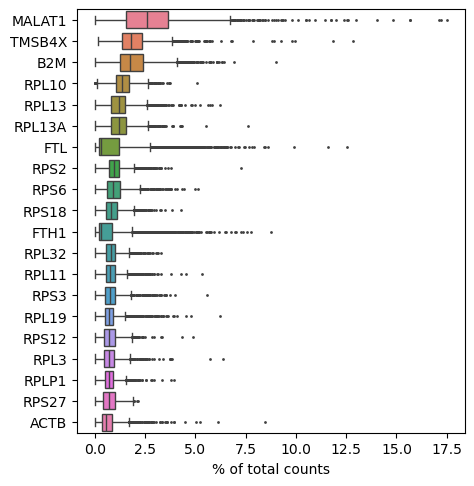

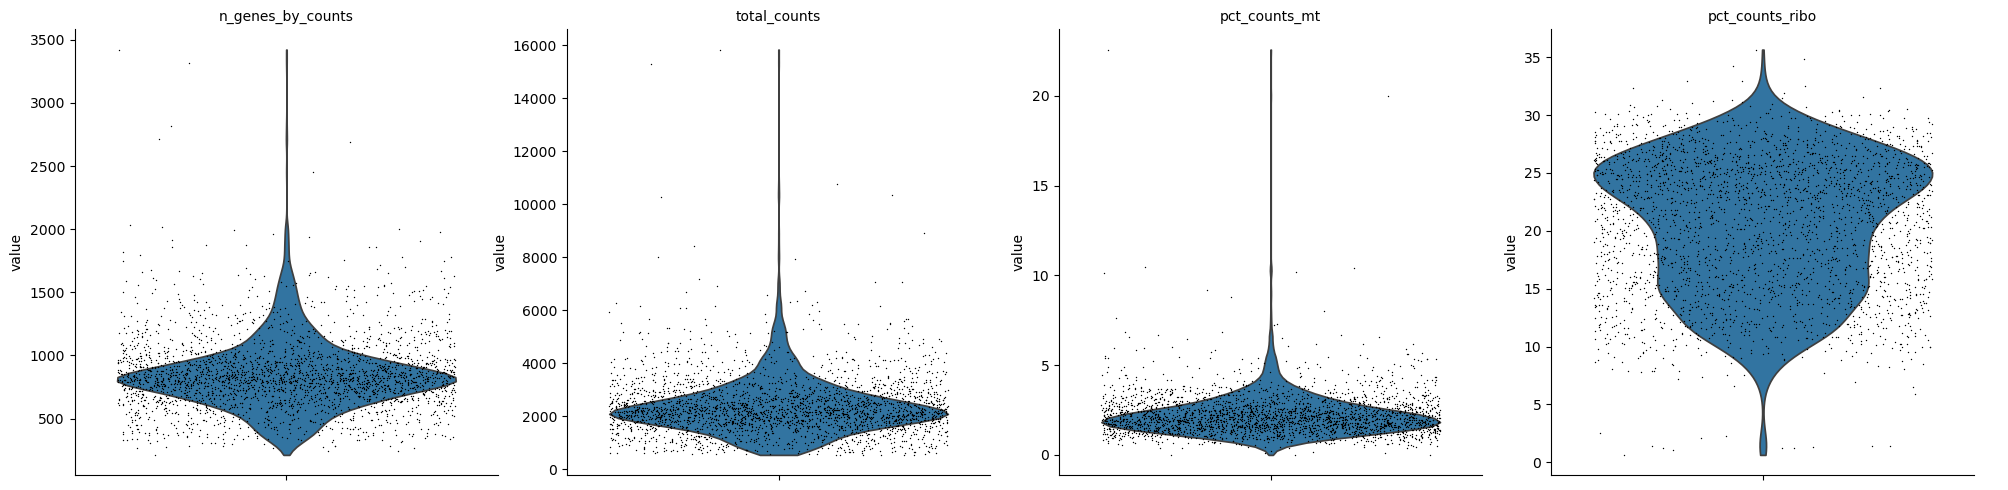

In [6]:
# make unique_gene name
adata.var_names_make_unique()

# calculate mt-, ribo- percentage
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith('RPL','RPS')

sc.pp.calculate_qc_metrics(adata=adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

# check the top 20 highly expressed genes per cell, which you can see are mainly housekeeping genes MALAT1, TMSB4X, ribosomal gene starting with RPL.
sc.pl.highest_expr_genes(adata, n_top=20) 

# violin plot of QC
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
    jitter=0.4,
    multi_panel=True,
)


""" Plot interpreation
The median gene counts per cell ~800, the median read counts per cell ~2000. 
Spatial data is challenge to get these numbers, expecialy stereo-seq (FF and FFPE). The cell bin total transcripts only 600-1200. The really bad cells have less than 600, which failed for clustering most of the time.
Note the low mt% percentage and high ribo% in single-cell data.

"""


<Axes: xlabel='total_counts', ylabel='n_genes_by_counts'>

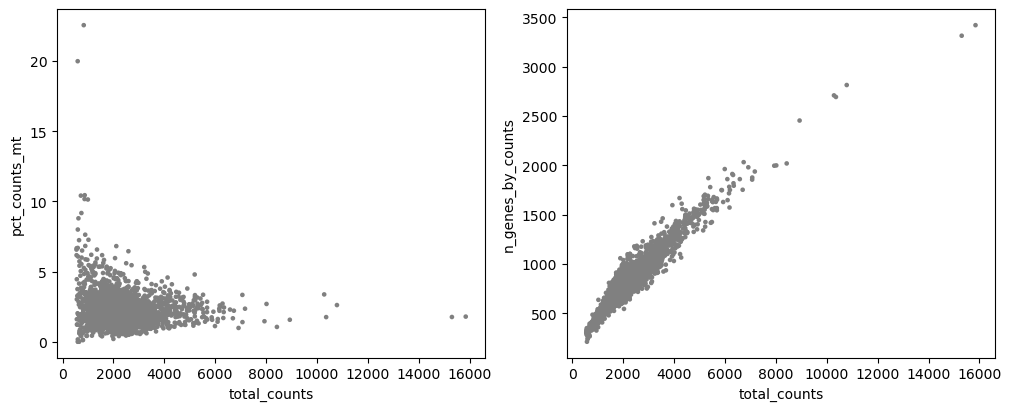

In [7]:
""" 
The two plots are what we expected.
More dead cells mean higher mt%, so we expect to see as the total_counts increase, the mt% decrease.
we expect to see linear relationship between total_counts and n_genes_by_counts.
"""

fig, axs = plt.subplots(1,2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', show=False, ax=axs[0])
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', show=False, ax=axs[1])



### 3) filter your data based on QC step

In [9]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)


adata = adata[
    (adata.obs.n_genes_by_counts < 2500) & (adata.obs.n_genes_by_counts > 200) & (adata.obs.pct_counts_mt < 5), :
].copy()


# This is very important. Running this code always guarrantte your to recover your data later, and the `counts` layer is required for furter downstream analysis or subclustering.
adata.layers["counts"] = adata.X.copy()


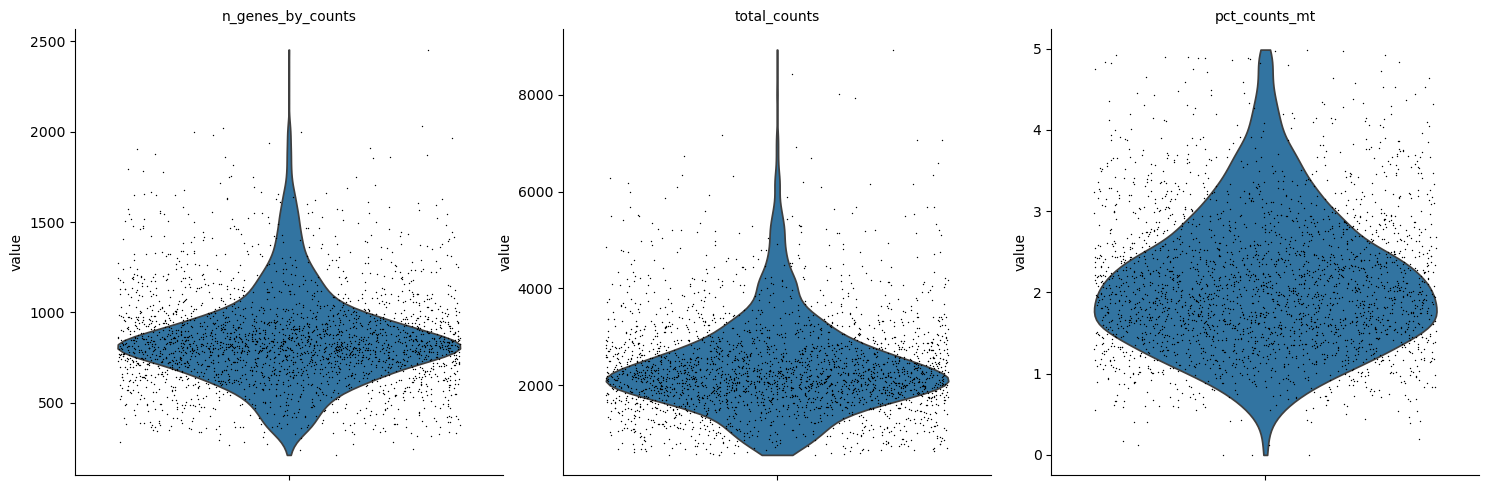

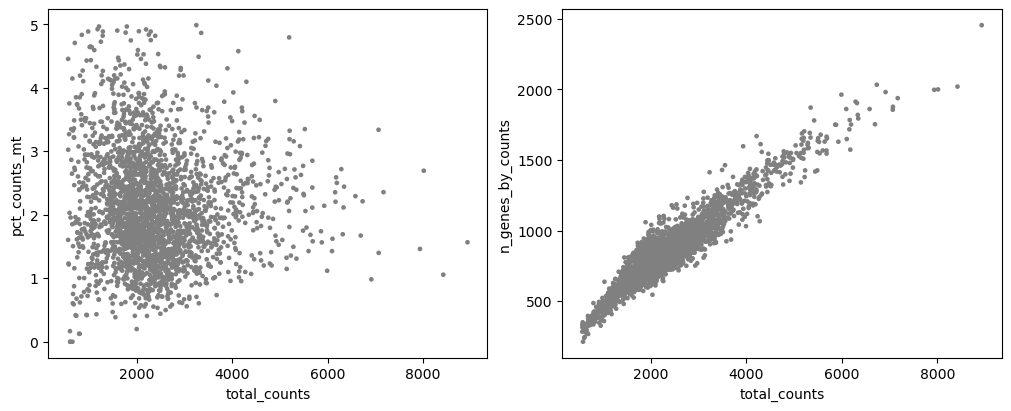

In [11]:
# After QC plots

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1]);

### 4) normalization

In [12]:
# 4-1 library-size correct: total-count normalize the data matrix X to 10,000 reads per cell, so that counts become comparable among cells
sc.pp.normalize_total(adata, target_sum=1e4)

# 4-2 Logarithmize the data
sc.pp.log1p(adata)

# This is important to save the normalize data for downstream DEG analysis.
adata.layers["lognorm"] = adata.X.copy()


### 5) Find highly variable genes  
single-cell data contains thousands of genes, we want to only focus on the main genes that carry the biological variation. Normally, we use the top 2000 highly variable genes.

Note:   
    1) this step allows you to determine that you want to do `subset=True` or `subset=False`. if set to True, the matrix in `layers` will also be subset, and you can't recover it if you want to do subclustering based on the `subset=True` clustering results. For noise data, I prefer to set `subset=False`, so I can easily recover the matrix data for subclustering analysis.  

    2) for **spatial data** with very high mt% and ribo% or other unwanted housekeeping genes, it's better to remove these genes before finding hvg, otherwise, the marker genes will be dominant by these annoying genes which can't give you good biological interpretation.

##### 
For dealing with mt-, ribo- genes, or any unwanted highly expressed housekeeping genes. 
Based on the biological question that if the mt- or ribo- is part of the question you are interested. If yes, DO NOT remove or ignore them. If not, normally have three options to handle them.
1) exclude them before normalizing, exclude them during filtering step.
    those massive ribosomal/mitochondrial reads are excluded from the cell sum. 

2) exclude them after normalizing,
    Their reads were factored into the scaling math. `sc.pp.normalize_total(adata, target_sum=1e4)`, Scanpy computes a scaling factor for each cell based on the sum of all genes in that cell.  

3) ignoring them by mask them as false hvg.


Both approaches 1) and 2) are heavily used in peer-reviewed literature <https://www.reddit.com/r/bioinformatics/comments/1lprtdp/exclude_mitochondrial_ribosomal_and/>. Filtering after normalization simply means your normalized cells are scaled relative to the entire sequenced transcript pool (including tech-noise), rather than just the clean biological pool.

You can test-out which best fits your data.

The result of the previous highly-variable-genes detection is stored as an annotation in .var["highly_variable"] and auto-detected by PCA and hence, sc.pp.neighbors and subsequent manifold/graph tools. 


In [16]:
# 1) or 2) Exclude uninformative biological genes
# Example code to remove mt%, ribo%, unwanted genes before calling hvg

# remove dominant housekeeping genes
unwanted_genes = ['MALAT1', 'B2M','TMSB10','ACTB','EEF1A1']
unwanted_mask = adata.var_names.isin(unwanted_genes)
keep_genes = ~(adata.var['mt'] | adata.var['ribo'] | unwanted_mask)
adata = adata[:, keep_genes].copy()


sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
    n_top_genes=2000,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5,
    layer="counts",
    subset=False # guaranttee downstream analysis
)


In [ ]:
# # 3) ignore genes: exclude mt- and ribo- from hvg
# ignore_genes = adata.var['mt'] | adata.var['ribo']

# sc.pp.highly_variable_genes(
#     adata,
#     flavor='seurat_v3',
#     n_top_genes=2000,
#     layer="counts",
#     subset=False
# )

# # Overwrite the highly_variable status of MT/Ribo genes to False
# # 1. Clear the main boolean flag
# adata.var.loc[ignore_genes, 'highly_variable'] = False

# # 2. Wipe out the ranking metrics for these ignored genes
# if 'highly_variable_rank' in adata.var.columns:
#     adata.var.loc[ignore_genes, 'highly_variable_rank'] = np.nan


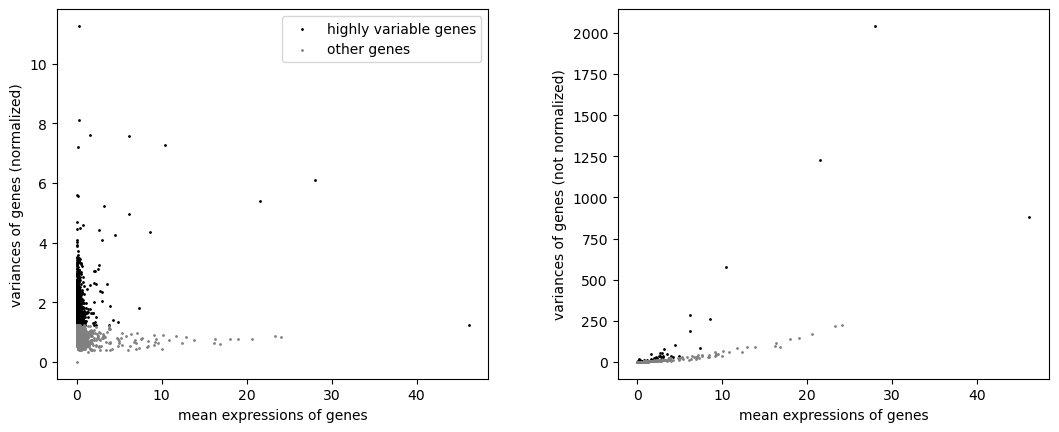

In [17]:
# Plot highly variable genes
sc.pl.highly_variable_genes(adata)



### 6) regress out covariates (confounding variable), ex. total_counts, ribo- genes, etc
we need to run both regress_out and scaling steps as they perform entirely different mathematical operations on your data.   
In scanpy, regress_out removes the variance caused by unwanted technical factors, while scale ensures all genes contribute equally to downstream PCA

`sc.pp.regress_out` (Linear Regression): This fits a linear model using your covariates (like pct_counts_mt) to predict gene expression. It then subtracts that prediction, leaving only the residuals (the expression unexplained by stress or technical noise).  

`sc.pp.scale` (Z-score Scaling): Without this, highly expressed genes would dominate your PCA and clustering simply because their numerical counts are larger.

In [18]:
adata.layers["scaled"] = adata.X.toarray()
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"], layer="scaled")


### 7) scale the data

In [19]:
# We want to keep the biological variance of the genes, not bring them down to 0, which makes it impossible to compare.
# Scale each gene to unit variance. Clip values exceeding standard deviation 10. 
sc.pp.scale(adata, zero_center=False, max_value=10, layer="scaled")



### 8) dimentionality reduction (PCA)
Reduce the dimensionality of the data by running PCA, which reveals the main axes of variation and denoise the data.



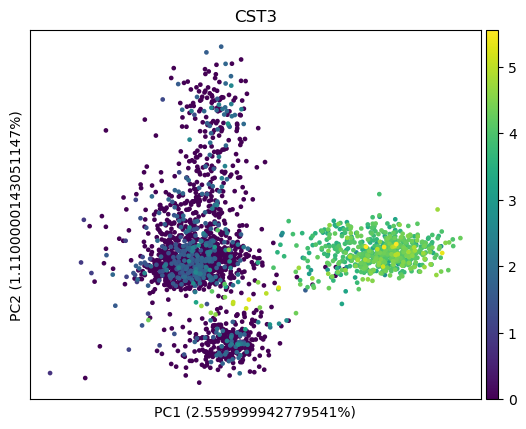

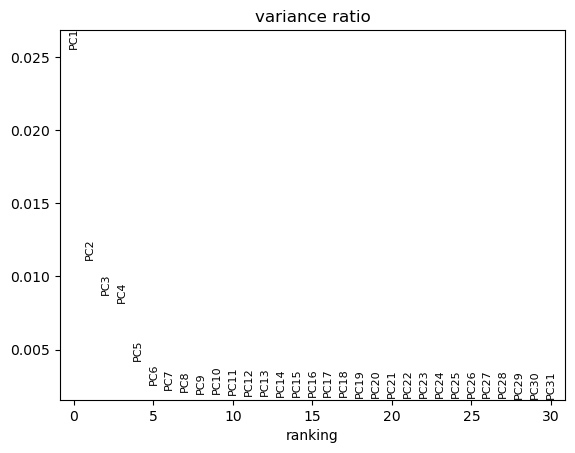

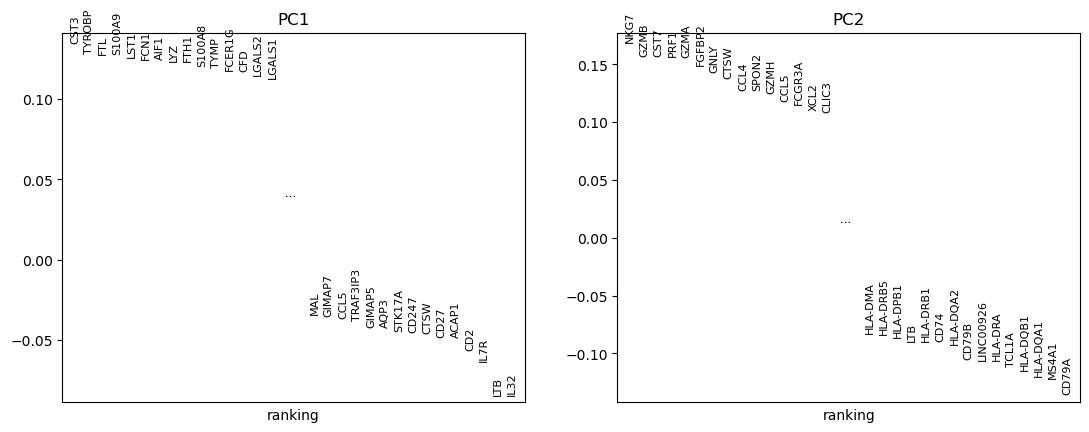

In [23]:
# sc.pp.pca(adata, layer="scaled", svd_solver="arpack")

# visualize gene "CST53" comes from which PCs
sc.pl.pca(adata, annotate_var_explained=True, color="CST3")

# PCs elbow plot. Note the percentage of each PC accounts, which is low, and normal in single-cell and spatial data
sc.pl.pca_variance_ratio(adata, n_pcs=30) 

# which genes contribute to the main PCs
sc.pl.pca_loadings(adata, components=(1, 2), include_lowest=True)


### 9) Find neighbors  
Compute the neighborhood graph of cells using PC representation of the data matrix. We can just use default value. 
Note,   

Biological Context                                         Preferred n_neighbors    Graph Focus  
Continuous/Gradients(Fibroblasts, Stem cell differentiation)  Low (5 - 15)       Local micro-structure & trajectories  
Discrete/Distinct (PBMCs, Mixed tissue cell lineages)         High(20 - 50+)     Global macro-structure & stable clusters  

If you want to identify more sparse cells, new cells, may include n_pcs.

In [24]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

/home/lchen/miniconda3/envs/squidpy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 10) Embedding the neighborhood graph (UMAP)  
Suggesting embedding the graph in two dimensions using UMAP.

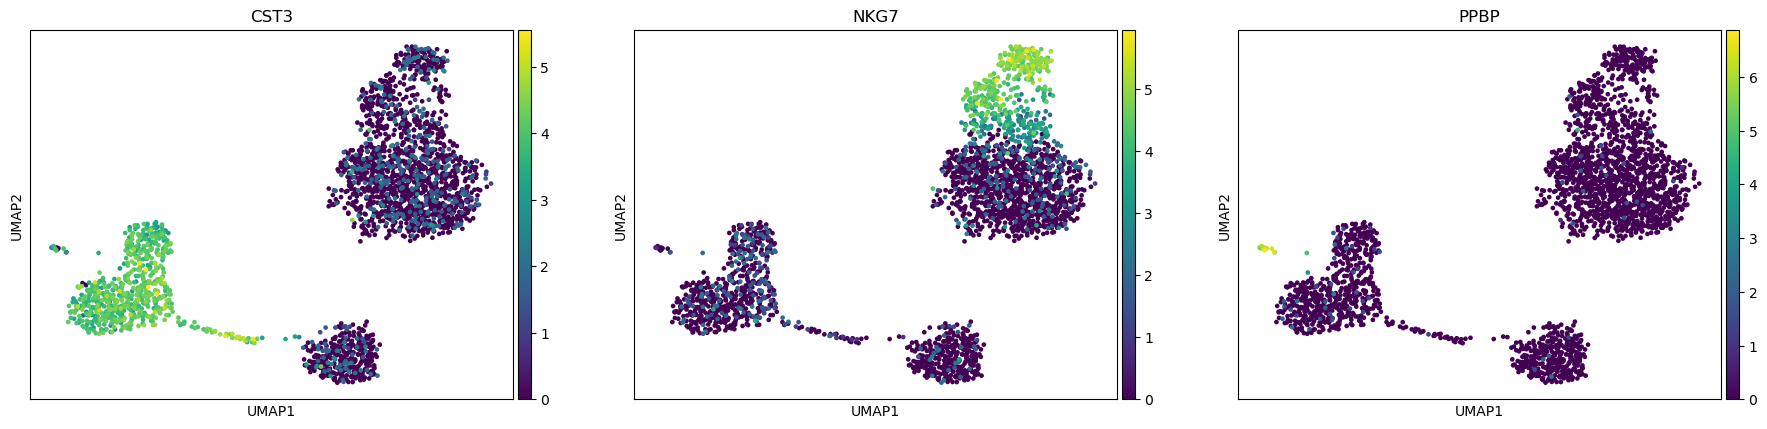

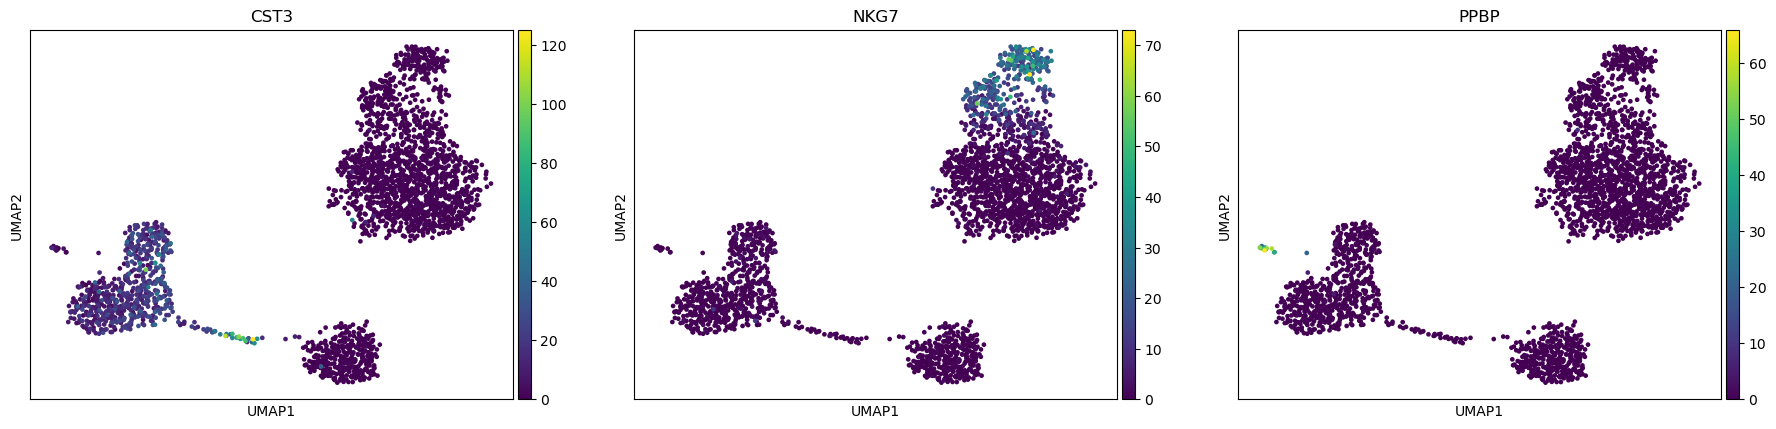

In [27]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=['CST3', 'NKG7', 'PPBP']) # this by default using normalized data

# use non-normalized data by specifying `layer`
sc.pl.umap(adata, color=["CST3", "NKG7", "PPBP"], layer="counts") 

### 11) clustering the neighborhood graph (leiden or louvei)

Leiden clustering is recommended. Adjust resolution to change the number of clusters.

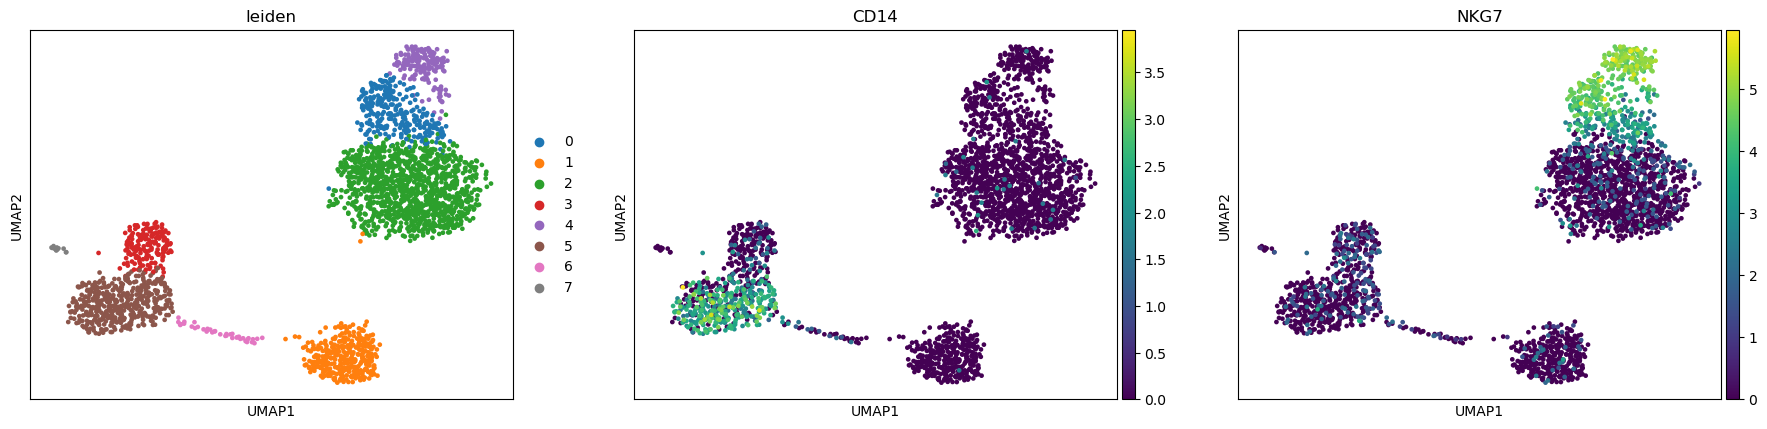

In [28]:
sc.tl.leiden(
    adata,
    resolution=0.7,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)
adata.obs["leiden"] = adata.obs["leiden"].copy()
adata.uns["leiden"] = adata.uns["leiden"].copy()
adata.obsm["X_umap"] = adata.obsm["X_umap"].copy()

# plot the clustering
sc.pl.umap(adata, color=["leiden", "CD14", "NKG7"])

### 12) Find marker genes

Find marker genes for each cluster. The two main method is `t-test` and `wilcoxon`.
t-test (Parametric): it mathematically assumes a normal distribution of the underlying populations. Single-cell gene expression counts are never normally distributed. They are highly skewed, contain many zeros (dropout), and follow a negative binomial distribution. Due to the Central Limit Theorem, if your cluster has a large number of cells (e.g., >30 cells), the distribution of the sample means becomes approximately normal. This makes the t-test highly robust and incredibly fast for large single-cell datasets, even if the raw counts violate normality. Violates normality assumption for small cluster performance.

wilcoxon(non-parametric): it does not assume a normal distribution. The Wilcoxon rank-sum test actually assumes that the shapes of the distributions for both groups being compared are relatively similar. If one cluster has a high expression with low dropout, and another has erratic expression with massive zero-dropout, the test can sometimes flag genes based on the shape of the noise rather than a clean difference in median expression. However, it is much better at handling skewed single-cell data than a t-test when your cell clusters are small. More reliable for small cell counts.

In [30]:
adata

AnnData object with n_obs × n_vars = 2638 × 13644
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'leiden'
    var: 'gene_ids', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm', 'scaled'
    obsp: 'distances', 'connectivities'

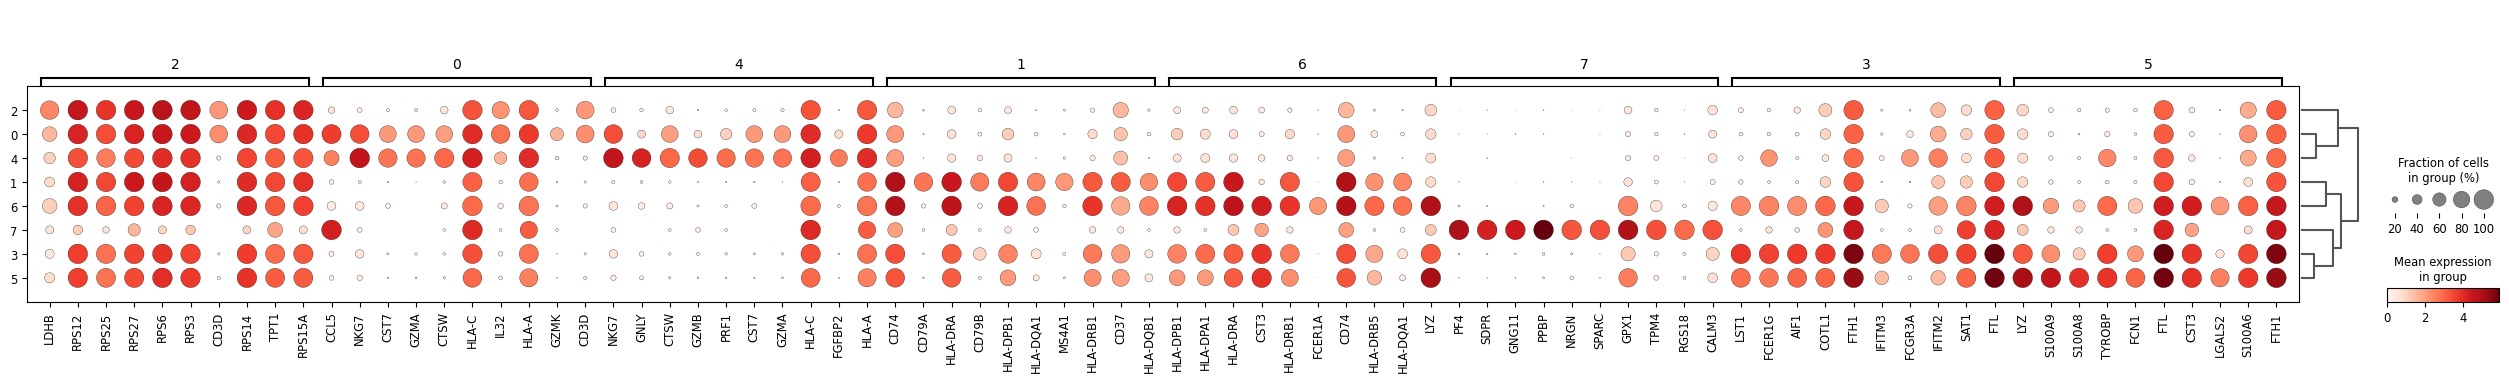

In [34]:
import pandas as pd


# Find markers
sc.tl.rank_genes_groups(
    adata, 
    groupby="leiden", 
    method='wilcoxon',
    layer="lognorm", 
    pts=True, 
    use_raw=False
)

# plot the cleaner dotplot
sc.pl.rank_genes_groups_dotplot(
    adata, 
    n_genes=10,
    #gene_symbols = "real_gene_name",
    use_raw=False
)

pd.set_option('display.max_rows', None)

# Extract positive marker genes for cell annotation
markers_df = sc.get.rank_genes_groups_df(
    adata, 
    key='rank_genes_groups',
    group=None,
    log2fc_min=0
)

markers_df = markers_df[markers_df['pvals_adj'] < 0.05]

# Save to CSV
markers_df.to_csv(f'{outdir}/markers_sig.csv', index=False)


### 13) annotation

In [35]:
new_cluster_names = [
    "CD4 T",
    "B",
    "CD14+ Monocytes",
    "NK",
    "CD8 T",
    "FCGR3A+ Monocytes",
    "Dendritic",
    "Megakaryocytes",
]
adata.rename_categories("leiden", new_cluster_names)


# # celltype mapping code:
# # Annotate cluster53 as B_cell
# cell_map = {
#     "53": "B_cell"
# }

# adata.obs["celltype"] = (
#     adata.obs['res0.1']
#     .astype(str)
#     .map(cell_map)
#     .fillna("Unknown")
# )


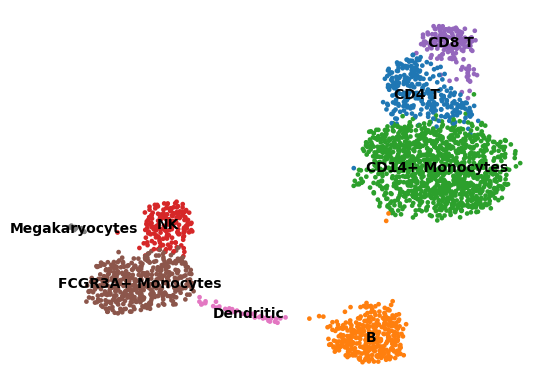

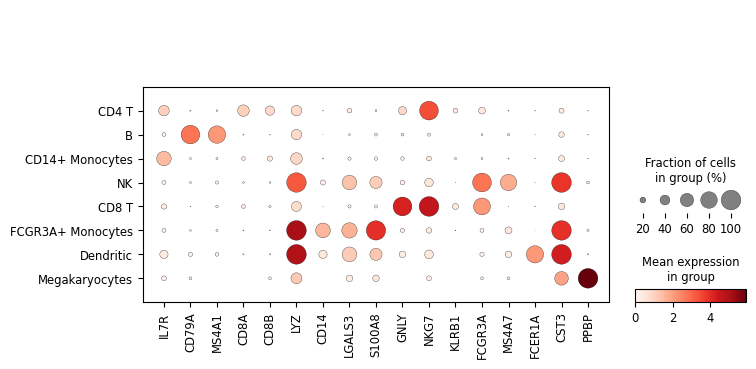

In [39]:
sc.pl.umap(adata, color="leiden", legend_loc="on data", title="", frameon=False)


marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]
sc.pl.dotplot(adata, marker_genes, groupby="leiden")

### 14) save anndata

In [38]:
adata.write(f"{outdir}/annotated.h5ad")

The analysis follows scanpy tutorial:
https://scanpy.scverse.org/en/stable/tutorials/basics/clustering-2017.html